# LUNA16 Lung Nodule Classifier

Binary classification of lung nodule candidates from CT scans.

**Dataset:** LUNA16 — 445 CT volumes, 275k+ annotated candidate locations  
**Model:** ResNet-18 (ImageNet pretrained), fine-tuned on 64×64 axial CT patches  
**Task:** Candidate classification — predict nodule (1) or non-nodule (0)

> Set `MINI_RUN = True` in the Configuration cell for a quick 2-minute pipeline test.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk
import subprocess
from pathlib import Path
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms

## 2. Configuration

All key settings live here. Set `MINI_RUN = True` for a quick 2-minute pipeline test, `False` for full training.

In [2]:
MINI_RUN = False   # True = quick test | False = full run

BASE_DIR   = Path("/kaggle/input/datasets/avc0706/luna16")
SUBSETS    = [BASE_DIR / f"subset{i}" / f"subset{i}" for i in range(5)]
CANDIDATES = BASE_DIR / "candidates.csv"
PATCH_DIR  = Path("/kaggle/working/patches")
PATCH_DIR.mkdir(exist_ok=True)

PATCH_SIZE = 64
HU_MIN     = -1000
HU_MAX     = 400

NEG_RATIO = {"train": 10, "val": 10, "test": 20}
POS_CAP   = {"train": 50, "val": 15, "test": 15} if MINI_RUN else {"train": 9999, "val": 9999, "test": 9999}

BATCH_SIZE     = 32 if MINI_RUN else 64
MAX_EPOCHS     = 20
EARLY_PATIENCE = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Mode:   {'MINI' if MINI_RUN else 'FULL'}")

Device: cuda
Mode:   FULL


## 3. Data Exploration

`candidates.csv` has one row per candidate with world-space coordinates (mm) and a binary label. The dataset has a **407:1 class imbalance**, addressed in Section 6 with weighted sampling and a weighted loss.

In [3]:
df = pd.read_csv(CANDIDATES)
print(f"Shape: {df.shape}")
print(df.head())
print(f"\nClass distribution:\n{df['class'].value_counts()}")
print(f"\nNegative:Positive ratio ≈ {df['class'].value_counts()[0] / df['class'].value_counts()[1]:.0f}:1")

Shape: (551065, 5)
                                           seriesuid  coordX  coordY  coordZ  \
0  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -56.08  -67.85 -311.92   
1  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...   53.21 -244.41 -245.17   
2  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  103.66 -121.80 -286.62   
3  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -33.66  -72.75 -308.41   
4  1.3.6.1.4.1.14519.5.2.1.6279.6001.100225287222...  -32.25  -85.36 -362.51   

   class  
0      0  
1      0  
2      0  
3      0  
4      0  

Class distribution:
class
0    549714
1      1351
Name: count, dtype: int64

Negative:Positive ratio ≈ 407:1


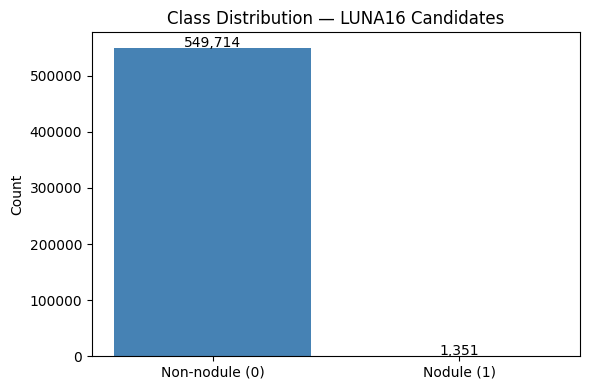

In [4]:
counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
bars = plt.bar(["Non-nodule (0)", "Nodule (1)"], counts.values, color=["steelblue", "tomato"])
plt.title("Class Distribution — LUNA16 Candidates")
plt.ylabel("Count")
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 500,
             f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

## 4. File Mapping and Splits

Each CT scan is a `.mhd` file named by its `seriesuid`. We build a lookup dictionary from seriesuid to file path, then assign splits **by subset** — not randomly.

**Why by subset?** Each LUNA16 subset contains different patients. Random splitting would put the same patient in both train and test, inflating results through data leakage.

| Split | Subsets |
|---|---|
| Train | 0, 1, 2 |
| Val | 3 |
| Test | 4 |

In [5]:
def build_uid_to_path(subset_dirs):
    uid_to_path = {}
    for subset_dir in subset_dirs:
        for mhd_file in Path(subset_dir).glob("*.mhd"):
            uid_to_path[mhd_file.stem] = mhd_file
    return uid_to_path

uid_to_path = build_uid_to_path(SUBSETS)
print(f"CT volumes found: {len(uid_to_path)}")

CT volumes found: 445


In [6]:
def get_subset_number(uid):
    path = uid_to_path.get(uid)
    if path is None:
        return None
    return int(path.parent.name.replace("subset", ""))

def assign_split(subset_num):
    if subset_num in [0, 1, 2]:
        return "train"
    elif subset_num == 3:
        return "val"
    else:
        return "test"

df["subset"] = df["seriesuid"].apply(get_subset_number)
df_filtered  = df.dropna(subset=["subset"]).copy()
df_filtered["subset"]   = df_filtered["subset"].astype(int)
df_filtered["split"]    = df_filtered["subset"].apply(assign_split)
df_filtered["mhd_path"] = df_filtered["seriesuid"].apply(lambda uid: str(uid_to_path[uid]))

print(f"Candidates after filtering: {len(df_filtered):,}")
print()
print(df_filtered.groupby(["split", "class"]).size().unstack(fill_value=0))

Candidates after filtering: 275,358

class       0    1
split             
test    54362  147
train  165568  433
val     54707  141


## 5. Patch Extraction

Three preprocessing steps applied to each CT volume:

1. **Resample to 1mm isotropic spacing** — different scanners produce different slice thicknesses. Resampling normalises voxel size so all 445 scans are comparable.
2. **World → voxel coordinates** — candidate locations are in millimetres. Converted to pixel indices via `voxel = (world - origin) / spacing`.
3. **Extract 64×64 patch from 3 axial slices** — slices z−1, z, z+1 become the 3 input channels ResNet expects. HU values are clipped to [−1000, 400] and scaled to [0, 1].

Patches are saved to disk before training — never re-extracted per epoch.  
**Runtime:** ~2 min (MINI) | ~20 min (FULL)

In [7]:
def resample_volume(sitk_image):
    original_spacing = sitk_image.GetSpacing()
    original_size    = sitk_image.GetSize()
    new_spacing      = [1.0, 1.0, 1.0]
    new_size = [
        int(round(original_size[i] * original_spacing[i] / new_spacing[i]))
        for i in range(3)
    ]
    resampler = sitk.ResampleImageFilter()
    resampler.SetOutputSpacing(new_spacing)
    resampler.SetSize(new_size)
    resampler.SetOutputDirection(sitk_image.GetDirection())
    resampler.SetOutputOrigin(sitk_image.GetOrigin())
    resampler.SetInterpolator(sitk.sitkLinear)
    resampler.SetDefaultPixelValue(-1000)
    return resampler.Execute(sitk_image)


def world_to_voxel(world_coord, origin, spacing):
    return np.round((np.array(world_coord) - origin) / spacing).astype(int)


def extract_patch(volume, voxel_coord):
    x, y, z = voxel_coord
    half     = PATCH_SIZE // 2
    z_dim, y_dim, x_dim = volume.shape

    if (z - 1 < 0 or z + 1 >= z_dim or
            y - half < 0 or y + half > y_dim or
            x - half < 0 or x + half > x_dim):
        return None

    channels = [
        volume[z + dz, y - half : y + half, x - half : x + half]
        for dz in [-1, 0, 1]
    ]
    patch = np.stack(channels, axis=0).astype(np.float32)
    patch = np.clip(patch, HU_MIN, HU_MAX)
    patch = (patch - HU_MIN) / (HU_MAX - HU_MIN)
    return patch

In [8]:
def extract_split(df_split, split_name):
    all_pos   = df_split[df_split["class"] == 1]
    positives = all_pos.sample(n=min(POS_CAP[split_name], len(all_pos)), random_state=42)
    all_neg   = df_split[df_split["class"] == 0]
    n_neg     = min(len(all_neg), len(positives) * NEG_RATIO[split_name])
    negatives = all_neg.sample(n=n_neg, random_state=42)

    df_use  = pd.concat([positives, negatives]).reset_index(drop=True)
    grouped = df_use.groupby("seriesuid")

    all_patches, all_labels, skipped = [], [], 0

    for i, (uid, group) in enumerate(grouped):
        sitk_img = sitk.ReadImage(group["mhd_path"].iloc[0])
        sitk_img = resample_volume(sitk_img)
        origin   = np.array(sitk_img.GetOrigin())
        spacing  = np.array(sitk_img.GetSpacing())
        volume   = sitk.GetArrayFromImage(sitk_img)

        for _, row in group.iterrows():
            world = np.array([row["coordX"], row["coordY"], row["coordZ"]])
            voxel = world_to_voxel(world, origin, spacing)
            patch = extract_patch(volume, voxel)
            if patch is None:
                skipped += 1
                continue
            all_patches.append(patch)
            all_labels.append(int(row["class"]))

        if (i + 1) % 20 == 0:
            print(f"  {split_name}: {i + 1}/{len(grouped)} series done")

    patches_arr = np.stack(all_patches)
    labels_arr  = np.array(all_labels)
    np.save(PATCH_DIR / f"patches_{split_name}.npy", patches_arr)
    np.save(PATCH_DIR / f"labels_{split_name}.npy",  labels_arr)
    print(f"{split_name} done — shape: {patches_arr.shape} | positives: {labels_arr.sum()} | skipped: {skipped}")


for split_name in ["train", "val", "test"]:
    extract_split(df_filtered[df_filtered["split"] == split_name], split_name)

print("\nExtraction complete.")

  train: 20/267 series done
  train: 40/267 series done
  train: 60/267 series done
  train: 80/267 series done
  train: 100/267 series done
  train: 120/267 series done
  train: 140/267 series done
  train: 160/267 series done
  train: 180/267 series done
  train: 200/267 series done
  train: 220/267 series done
  train: 240/267 series done
  train: 260/267 series done
train done — shape: (4652, 3, 64, 64) | positives: 416 | skipped: 111
  val: 20/89 series done
  val: 40/89 series done
  val: 60/89 series done
  val: 80/89 series done
val done — shape: (1481, 3, 64, 64) | positives: 128 | skipped: 70
  test: 20/89 series done
  test: 40/89 series done
  test: 60/89 series done
  test: 80/89 series done
test done — shape: (3048, 3, 64, 64) | positives: 144 | skipped: 39

Extraction complete.


## 6. Dataset and DataLoaders

Two mechanisms work together to address the 407:1 class imbalance:

1. **WeightedRandomSampler** — oversamples positives so each batch contains ~1 nodule per 4 non-nodules. Without this, batches would contain almost no nodules and the model learns to ignore them.
2. **`pos_weight` in BCEWithLogitsLoss** — penalises missing a real nodule 10× more than a false alarm.

Augmentation (flip, rotate) is training-only. Colour/brightness changes are excluded — HU values are physically calibrated and distorting them would corrupt clinical meaning.

In [9]:
class NoduleDataset(Dataset):
    def __init__(self, patches_path, labels_path, transform=None):
        self.patches   = np.load(patches_path)
        self.labels    = np.load(labels_path).astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        patch = torch.from_numpy(self.patches[idx])
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.transform:
            patch = self.transform(patch)
        return patch, label


train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
])

train_ds = NoduleDataset(PATCH_DIR / "patches_train.npy", PATCH_DIR / "labels_train.npy", transform=train_transform)
val_ds   = NoduleDataset(PATCH_DIR / "patches_val.npy",   PATCH_DIR / "labels_val.npy")
test_ds  = NoduleDataset(PATCH_DIR / "patches_test.npy",  PATCH_DIR / "labels_test.npy")

train_labels = train_ds.labels
n_pos        = int(train_labels.sum())
n_neg        = len(train_labels) - n_pos
print(f"Train — positives: {n_pos} | negatives: {n_neg} | ratio: {n_neg/n_pos:.1f}:1")

sample_weights = np.where(train_labels == 1, 1.0 / n_pos, 4.0 / n_neg)
sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights).float(),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,    num_workers=2, pin_memory=True)

patches_b, labels_b = next(iter(train_loader))
print(f"Batch shape:     {patches_b.shape}")
print(f"Batch pos count: {labels_b.sum().int().item()} / {len(labels_b)}")

Train — positives: 416 | negatives: 4236 | ratio: 10.2:1
Batch shape:     torch.Size([64, 3, 64, 64])
Batch pos count: 8 / 64


## 7. Model

ResNet-18 pretrained on ImageNet. Only the final layer is replaced — from 1000 classes to a single binary output.

**Why pretrained?** Even though ImageNet contains photographs and not CT scans, early convolutional layers learn general features (edges, textures, shapes) that transfer well. Fine-tuning adapts these to CT patches much faster than training from scratch with only ~400 labelled positives.

**Why ResNet-18?** Patches are 64×64. A deeper network (ResNet-50) offers no benefit at this resolution and takes ~3× longer to train.

In [10]:
model = models.resnet18(weights="IMAGENET1K_V1")
model.fc = nn.Linear(512, 1)
model = model.to(DEVICE)

pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=2, factor=0.5)

print(f"Output layer: {model.fc}")
print(f"pos_weight:   {pos_weight.item():.2f}")
print(f"Parameters:   {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 180MB/s]


Output layer: Linear(in_features=512, out_features=1, bias=True)
pos_weight:   10.18
Parameters:   11,177,025


## 8. Training

| Setting | Value |
|---|---|
| Loss | BCEWithLogitsLoss + pos_weight |
| Optimiser | Adam, lr=1e-4 |
| Scheduler | ReduceLROnPlateau — halves LR after 2 epochs without improvement |
| Early stopping | Patience=4 on val AUC |
| Metric | AUC-ROC — correct metric for severely imbalanced classification |

In [11]:
best_auc, patience_count = 0.0, 0
history = {"train_loss": [], "val_auc": []}

for epoch in range(1, MAX_EPOCHS + 1):

    model.train()
    running_loss = 0.0
    for patches, labels in train_loader:
        patches = patches.to(DEVICE)
        labels  = labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model(patches), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(labels)
    train_loss = running_loss / len(train_ds)

    model.eval()
    val_probs, val_targets = [], []
    with torch.no_grad():
        for patches, labels in val_loader:
            probs = torch.sigmoid(model(patches.to(DEVICE))).squeeze(1).cpu().numpy()
            val_probs.extend(probs)
            val_targets.extend(labels.numpy())

    val_auc = roc_auc_score(val_targets, val_probs)
    scheduler.step(val_auc)
    history["train_loss"].append(train_loss)
    history["val_auc"].append(val_auc)

    print(f"Epoch {epoch:02d}/{MAX_EPOCHS} | Train Loss: {train_loss:.4f} | Val AUC: {val_auc:.4f} | LR: {optimizer.param_groups[0]['lr']:.2e}")

    if val_auc > best_auc:
        best_auc, patience_count = val_auc, 0
        torch.save(model.state_dict(), "/kaggle/working/best_model.pth")
    else:
        patience_count += 1
        if patience_count >= EARLY_PATIENCE:
            print(f"\nEarly stopping at epoch {epoch}.")
            break

print(f"\nBest Val AUC: {best_auc:.4f}")

Epoch 01/20 | Train Loss: 1.4516 | Val AUC: 0.8021 | LR: 1.00e-04
Epoch 02/20 | Train Loss: 0.8739 | Val AUC: 0.8936 | LR: 1.00e-04
Epoch 03/20 | Train Loss: 0.5538 | Val AUC: 0.9406 | LR: 1.00e-04
Epoch 04/20 | Train Loss: 0.4308 | Val AUC: 0.9390 | LR: 1.00e-04
Epoch 05/20 | Train Loss: 0.3671 | Val AUC: 0.9658 | LR: 1.00e-04
Epoch 06/20 | Train Loss: 0.3022 | Val AUC: 0.9580 | LR: 1.00e-04
Epoch 07/20 | Train Loss: 0.2133 | Val AUC: 0.9539 | LR: 1.00e-04
Epoch 08/20 | Train Loss: 0.2035 | Val AUC: 0.9462 | LR: 5.00e-05
Epoch 09/20 | Train Loss: 0.1282 | Val AUC: 0.9529 | LR: 5.00e-05

Early stopping at epoch 9.

Best Val AUC: 0.9658


## 9. Training Curves

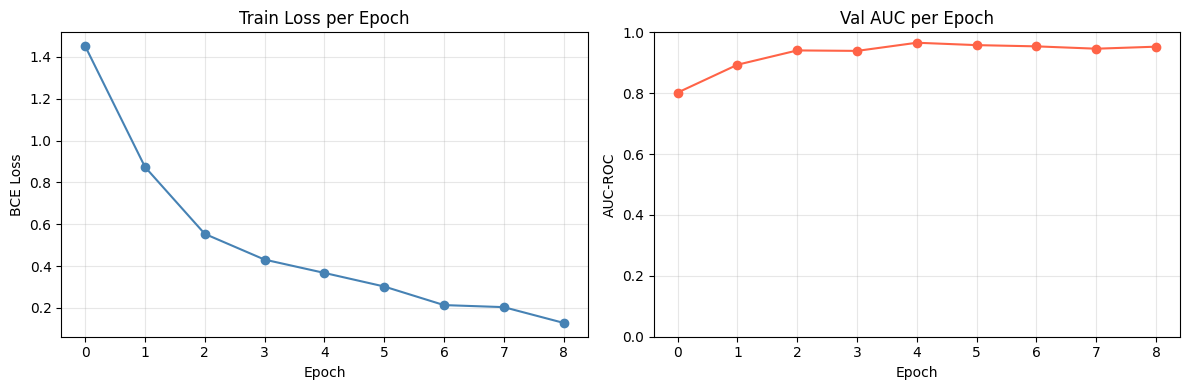

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history["train_loss"], marker="o", color="steelblue")
ax1.set_title("Train Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.grid(True, alpha=0.3)

ax2.plot(history["val_auc"], marker="o", color="tomato")
ax2.set_title("Val AUC per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("AUC-ROC")
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Test Evaluation

Evaluated on a held-out patient-disjoint test set (subset 4 — never seen during training or validation).

The decision threshold is chosen where **sensitivity ≥ 90%**. In lung cancer screening, missing a real nodule (false negative) is clinically more harmful than a false alarm (false positive).

In [13]:
model.load_state_dict(torch.load("/kaggle/working/best_model.pth"))
model.eval()

test_probs, test_targets = [], []
with torch.no_grad():
    for patches, labels in test_loader:
        probs = torch.sigmoid(model(patches.to(DEVICE))).squeeze(1).cpu().numpy()
        test_probs.extend(probs)
        test_targets.extend(labels.numpy())

test_probs   = np.array(test_probs)
test_targets = np.array(test_targets)

test_auc = roc_auc_score(test_targets, test_probs)
print(f"Test AUC-ROC: {test_auc:.4f}")

Test AUC-ROC: 0.9628


In [14]:
fpr, tpr, thresholds = roc_curve(test_targets, test_probs)

valid = [(tpr[i], 1 - fpr[i], thresholds[i]) for i in range(len(tpr)) if tpr[i] >= 0.90]
if valid:
    sensitivity, specificity, threshold = valid[0]
else:
    idx = np.argmin(np.abs(tpr - 0.90))
    sensitivity, specificity, threshold = tpr[idx], 1 - fpr[idx], thresholds[idx]

print(f"Threshold:   {threshold:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

preds = (test_probs >= threshold).astype(int)
cm    = confusion_matrix(test_targets, preds)
print(f"\nConfusion matrix:")
print(f"  TN={cm[0,0]:4d}  FP={cm[0,1]:4d}")
print(f"  FN={cm[1,0]:4d}  TP={cm[1,1]:4d}")

Threshold:   0.5985
Sensitivity: 0.9028
Specificity: 0.9294

Confusion matrix:
  TN=2699  FP= 205
  FN=  14  TP= 130


## 11. Grad-CAM

Grad-CAM highlights which regions of each patch most influenced the model's prediction. Red = high attention, blue = low attention.

Four examples from each outcome — the **false positive** and **false negative** cases are the most informative: they show where and why the model fails.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 108.4 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

TP:4  TN:4  FP:4  FN:4


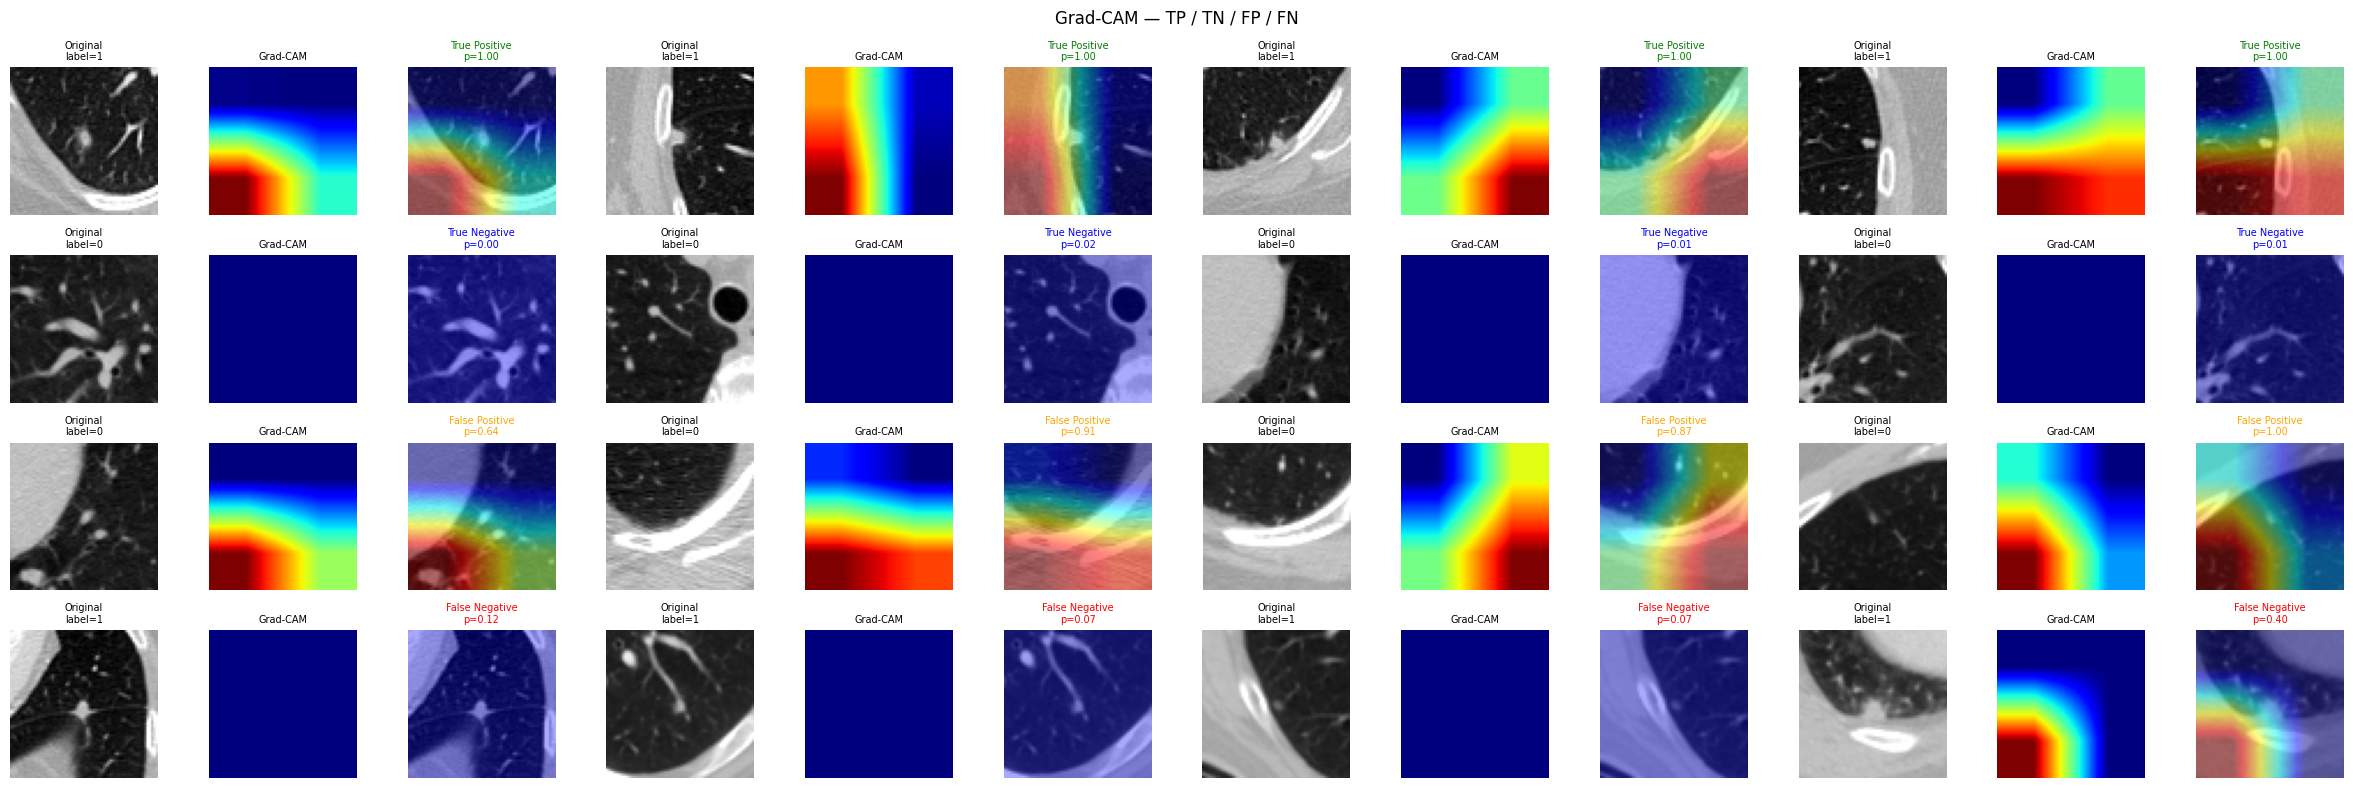

In [15]:
subprocess.run(["pip", "install", "grad-cam", "-q"])
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

cam = GradCAM(model=model, target_layers=[model.layer4[-1]])

results = list(zip(test_targets, test_probs, range(len(test_targets))))
tp = [(t, p, i) for t, p, i in results if t == 1 and p >= threshold][:4]
tn = [(t, p, i) for t, p, i in results if t == 0 and p <  threshold][:4]
fp = [(t, p, i) for t, p, i in results if t == 0 and p >= threshold][:4]
fn = [(t, p, i) for t, p, i in results if t == 1 and p <  threshold][:4]

print(f"TP:{len(tp)}  TN:{len(tn)}  FP:{len(fp)}  FN:{len(fn)}")

categories = [("True Positive",  tp, "green"),
              ("True Negative",  tn, "blue"),
              ("False Positive", fp, "orange"),
              ("False Negative", fn, "red")]

fig, axes = plt.subplots(4, 12, figsize=(24, 8))

for row_idx, (cat_name, samples, color) in enumerate(categories):
    for col_offset, (true_label, prob, idx) in enumerate(samples):
        patch   = torch.from_numpy(test_ds.patches[idx]).unsqueeze(0).to(DEVICE)
        heatmap = cam(input_tensor=patch)[0]
        centre  = test_ds.patches[idx][1]
        rgb     = np.stack([centre] * 3, axis=-1)
        overlay = show_cam_on_image(rgb, heatmap, use_rgb=True)
        c = col_offset * 3

        axes[row_idx, c].imshow(centre, cmap="gray", vmin=0, vmax=1)
        axes[row_idx, c].set_title(f"Original\nlabel={int(true_label)}", fontsize=7)
        axes[row_idx, c].axis("off")

        axes[row_idx, c+1].imshow(heatmap, cmap="jet", vmin=0, vmax=1)
        axes[row_idx, c+1].set_title("Grad-CAM", fontsize=7)
        axes[row_idx, c+1].axis("off")

        axes[row_idx, c+2].imshow(overlay)
        axes[row_idx, c+2].set_title(f"{cat_name}\np={prob:.2f}", fontsize=7, color=color)
        axes[row_idx, c+2].axis("off")

    for col_offset in range(len(samples), 4):
        for c in range(3):
            axes[row_idx, col_offset * 3 + c].axis("off")

plt.suptitle("Grad-CAM — TP / TN / FP / FN", fontsize=12)
plt.tight_layout()
plt.show()